In [43]:
import pandas as pd
import numpy as np

In [9]:
!pip install yfinance

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/949.2 kB ? eta -:--:--
     - ------------------------------------- 30.7/949.2 kB 1.3 MB/s eta 0:00:01
     ----- -------------------------------- 143.4/949.2 kB 2.1 MB/s eta 0:00:01
     ---------- --------------------------- 256.0/949.2 kB 2.0 MB/s eta 0:00:01
     ------------- ------------------------ 337.9/949.2 kB 2.1 MB/s eta 0:00:01
     ----------------- -------------------- 430.1/949.2 kB 1.9 MB/s eta 0:00:01
     -------------------- ----------------- 512.0/949.2 kB 2.1 MB/s eta 0:00:01
     -------------------------- ----------- 665.6/949.2 kB 2.1 MB/s eta 0:00:01
     -------------------------------- ----- 809.0/949.2 kB 2.2 MB/s eta 0:00:01
     ----------------------------------- -- 890.9/949.2 kB 2.2 MB/s eta 0:00:01
     -------------------------------------- 949.2/949.2 kB 2.1 MB/s eta 0:00:00
  Installing build depend

In [10]:
import yfinance as yf

In [29]:
9data = yf.download(["AAPL"], start="2024-01-01", end="2024-12-31", auto_adjust=False)
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2024-01-02,184.081512,185.639999,188.440002,183.889999,187.149994,82488700
2024-01-03,182.703171,184.250000,185.880005,183.429993,184.220001,58414500
2024-01-04,180.382812,181.910004,183.089996,180.880005,182.149994,71983600
2024-01-05,179.658951,181.179993,182.759995,180.169998,181.990005,62379700
2024-01-08,184.002182,185.559998,185.600006,181.500000,182.089996,59144500


In [37]:
data['R'] = data['Adj Close']['AAPL'].pct_change()
data.head()

Price,Adj Close,Close,High,Low,Open,Volume,R
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,,
2024-01-02,184.081512,185.639999,188.440002,183.889999,187.149994,82488700,NaN
2024-01-03,182.703171,184.250000,185.880005,183.429993,184.220001,58414500,-0.007488
2024-01-04,180.382812,181.910004,183.089996,180.880005,182.149994,71983600,-0.012700
2024-01-05,179.658951,181.179993,182.759995,180.169998,181.990005,62379700,-0.004013
2024-01-08,184.002182,185.559998,185.600006,181.500000,182.089996,59144500,0.024175


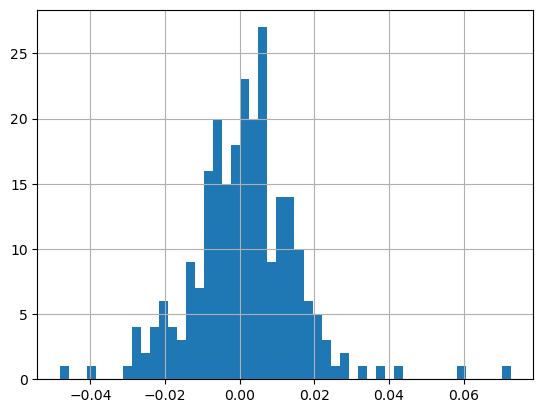

In [41]:
ax = data.R.hist(bins=50)

In [47]:
data.index = pd.to_datetime(data.index)
monthly_ret = data.R.resample('M').agg(lambda x: (1 + x).prod() -1)
monthly_ret = monthly_ret.to_frame()
monthly_ret.head()

C:\Users\Samual\AppData\Local\Temp\ipykernel_4652\303121184.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ret = data.R.resample('M').agg(lambda x: (1 + x).prod() -1)


,R
Date,
2024-01-31,-0.006680
2024-02-29,-0.018543
2024-03-31,-0.051286
2024-04-30,-0.006706
2024-05-31,0.130222


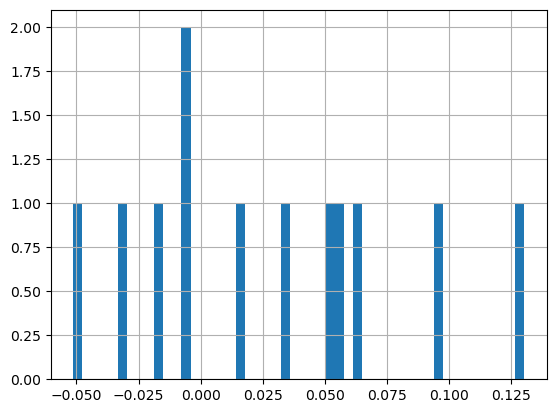

In [51]:
axs = monthly_ret.R.hist(bins=50)

In [53]:
monthly_ret.R.mean()

0.027560346476429538

In [67]:
import matplotlib.pyplot as plt
import scipy.stats as stats

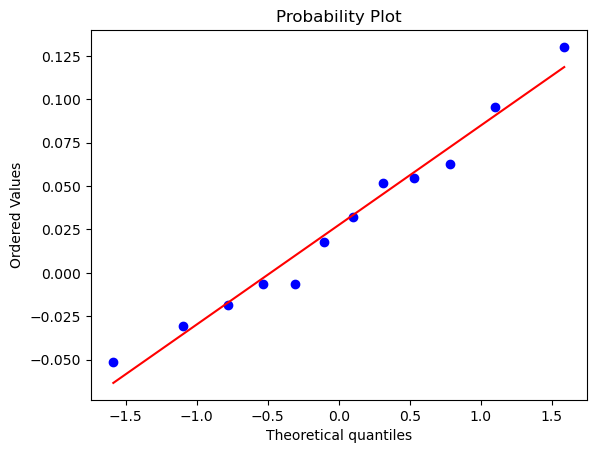

In [71]:
stats.probplot(monthly_ret.R, dist="norm", plot=plt); #normal tend not to be used

In [73]:
monthly_ret.R.quantile([0.25, 0.5, 0.75])

0.25   -0.009665
0.50    0.024910
0.75    0.056472
Name: R, dtype: float64

<Axes: >

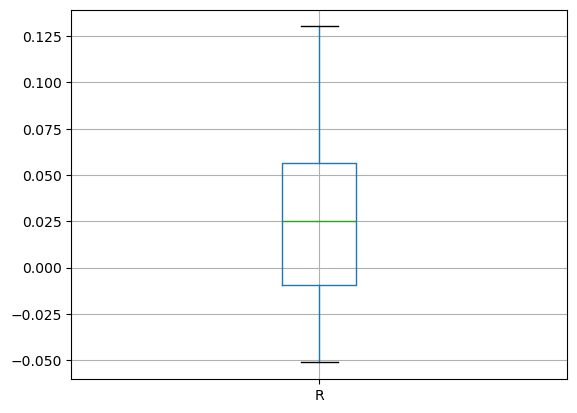

In [75]:
monthly_ret.boxplot('R')